# 01 — EDA & Preprocessing
**Member A — Data Engineer + EDA Lead**

Loads the raw `online_retail_II.xlsx`, applies cleaning, engineers RFM + behavioral features, labels churn, and produces all figures for the report's *Dataset* and *Preprocessing* sections.

**Outputs:** `data/processed/transactions_clean.parquet`, `rfm_features.csv` (clustering), `classification_features.csv` (pre-cutoff, churn classifier), `churn_labels.csv`, and figures under `reports/figures/`.

In [1]:
from __future__ import annotations
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import seed_all, savefig, DATA_PROCESSED
from src.plot_style import apply_style, PALETTE
from src import preprocessing as pp

seed_all(); apply_style()

## 1. Load raw data

In [2]:
raw = pp.load_raw()
print(f'Rows: {len(raw):,}')
raw.head()

Rows: 1,067,371


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
raw.info()
print('\nNulls per column:')
raw.isna().sum().to_frame('null_count')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB

Nulls per column:


,null_count
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


## 2. Cleaning

In [4]:
df = pp.clean(raw)
print(f'After cleaning: {len(df):,} rows  ({len(raw)-len(df):,} dropped, {(1-len(df)/len(raw))*100:.1f}%)')
df.head()

After cleaning: 805,549 rows  (261,822 dropped, 24.5%)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Country,CustomerID,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,United Kingdom,13085,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,United Kingdom,13085,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,United Kingdom,13085,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,United Kingdom,13085,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,United Kingdom,13085,30.0


In [5]:
summary = pd.DataFrame({
    'rows':            [len(raw), len(df)],
    'unique_customers':[raw['Customer ID'].nunique(), df['CustomerID'].nunique()],
    'unique_invoices': [raw['Invoice'].nunique(), df['Invoice'].nunique()],
    'unique_stockcodes':[raw['StockCode'].nunique(), df['StockCode'].nunique()],
    'countries':       [raw['Country'].nunique(), df['Country'].nunique()],
}, index=['raw', 'cleaned'])
summary

,rows,unique_customers,unique_invoices,unique_stockcodes,countries
raw,1067371,5942,53628,5305,43
cleaned,805549,5878,36969,4631,41


## 3. EDA — Univariate distributions

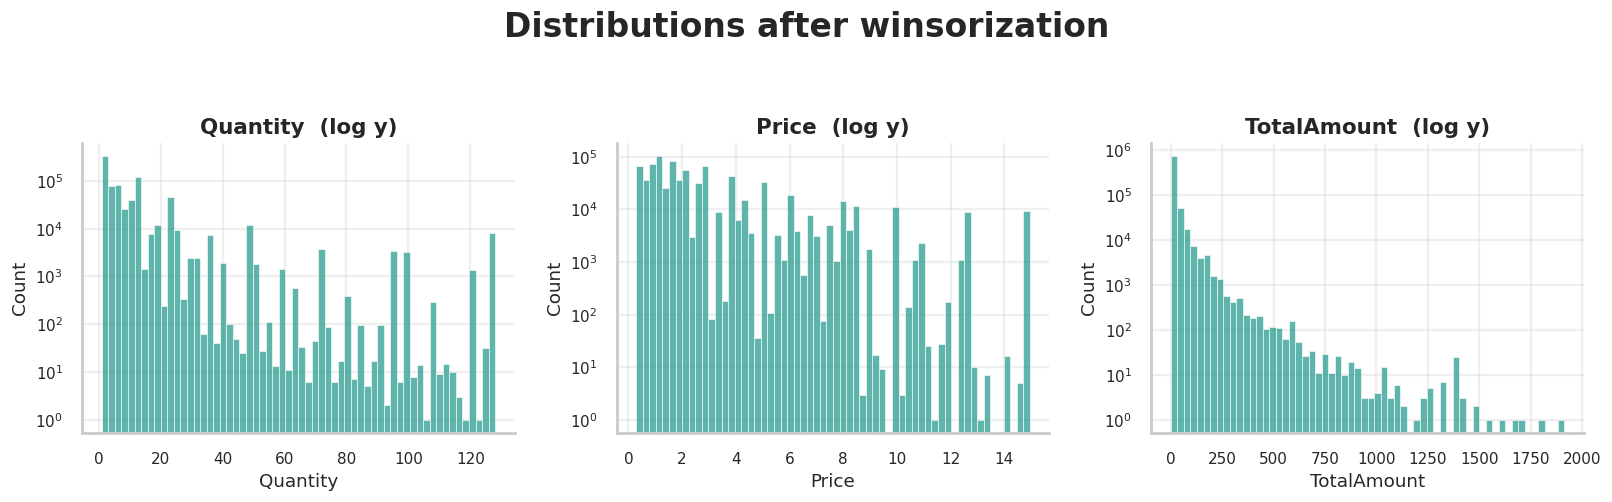

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ['Quantity', 'Price', 'TotalAmount']):
    sns.histplot(df[col], bins=60, ax=ax, color=PALETTE[1], edgecolor='white')
    ax.set_yscale('log'); ax.set_title(f'{col}  (log y)')
fig.suptitle('Distributions after winsorization', y=1.03, fontweight='bold')
fig.tight_layout(); savefig(fig, '01_distributions'); plt.show()

## 4. EDA — Monthly revenue

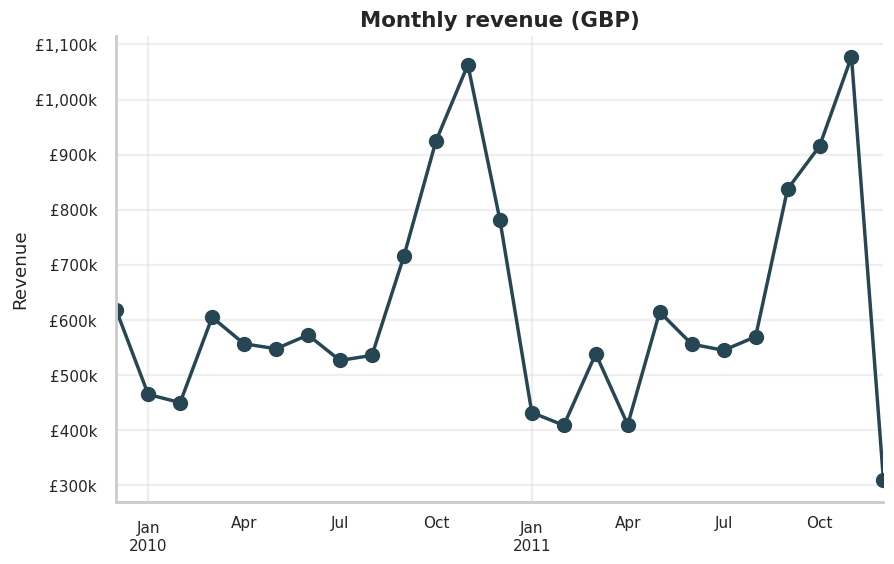

In [7]:
monthly = df.assign(month=df['InvoiceDate'].dt.to_period('M')).groupby('month')['TotalAmount'].sum()
monthly.index = monthly.index.to_timestamp()
fig, ax = plt.subplots()
monthly.plot(ax=ax, marker='o', color=PALETTE[0])
ax.set_title('Monthly revenue (GBP)'); ax.set_ylabel('Revenue'); ax.set_xlabel(None)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e3:,.0f}k'))
savefig(fig, '01_monthly_revenue'); plt.show()

## 5. EDA — Top products & top countries

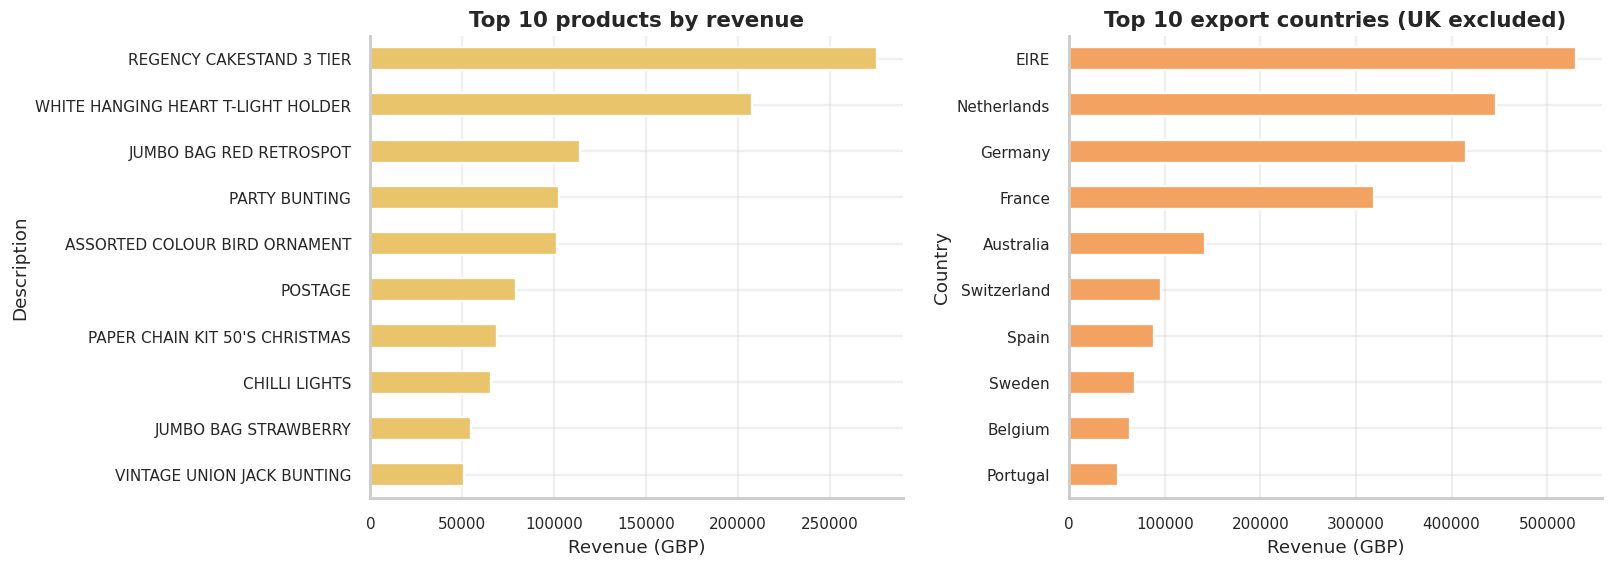

In [8]:
top_products = (df.groupby('Description')['TotalAmount'].sum()
                  .nlargest(10).sort_values())
top_countries = (df[df['Country'] != 'United Kingdom']
                  .groupby('Country')['TotalAmount'].sum()
                  .nlargest(10).sort_values())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
top_products.plot.barh(ax=axes[0], color=PALETTE[2])
axes[0].set_title('Top 10 products by revenue'); axes[0].set_xlabel('Revenue (GBP)')
top_countries.plot.barh(ax=axes[1], color=PALETTE[3])
axes[1].set_title('Top 10 export countries (UK excluded)'); axes[1].set_xlabel('Revenue (GBP)')
fig.tight_layout(); savefig(fig, '01_top_products_countries'); plt.show()

## 6. EDA — Customer Pareto (80/20 rule)

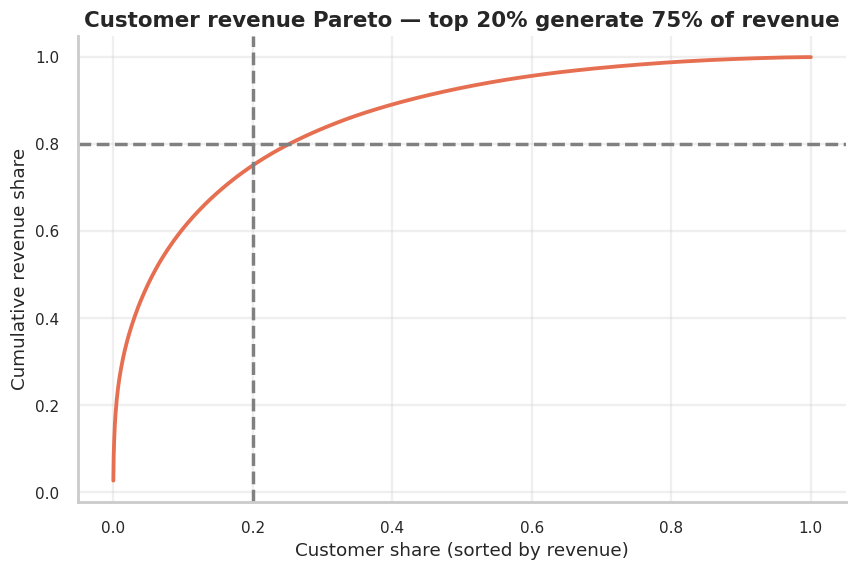

In [9]:
cust_rev = df.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False)
cum_share = cust_rev.cumsum() / cust_rev.sum()
x = np.linspace(0, 1, len(cust_rev))

fig, ax = plt.subplots()
ax.plot(x, cum_share.values, color=PALETTE[4], linewidth=2.5)
ax.axhline(0.8, ls='--', color='gray'); ax.axvline(0.2, ls='--', color='gray')
p20 = cum_share.iloc[int(0.2*len(cust_rev))]
ax.set_title(f'Customer revenue Pareto — top 20% generate {p20:.0%} of revenue')
ax.set_xlabel('Customer share (sorted by revenue)'); ax.set_ylabel('Cumulative revenue share')
savefig(fig, '01_pareto'); plt.show()

## 7. RFM features

In [10]:
rfm = pp.make_rfm(df).merge(pp.make_behavioral_features(df), on='CustomerID')
rfm.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
CustomerID,5878.0,15315.313542,1715.572666,12346.0,13833.25,15314.5,16797.75,18287.0
Recency,5878.0,200.866791,209.353961,0.0,25.0,95.0,379.0,738.0
Frequency,5878.0,6.289384,13.009406,1.0,1.0,3.0,7.0,398.0
Monetary,5878.0,2650.488171,10836.759579,2.95,336.6325,858.295,2207.145,421648.97
avg_basket_value,5878.0,342.73276,311.568521,2.95,175.075833,276.584444,406.053542,5814.186667
avg_basket_size,5878.0,200.49911,199.5497,1.0,93.0,153.633333,253.0,5704.0
unique_products,5878.0,81.989112,116.484552,1.0,19.0,45.0,103.0,2550.0


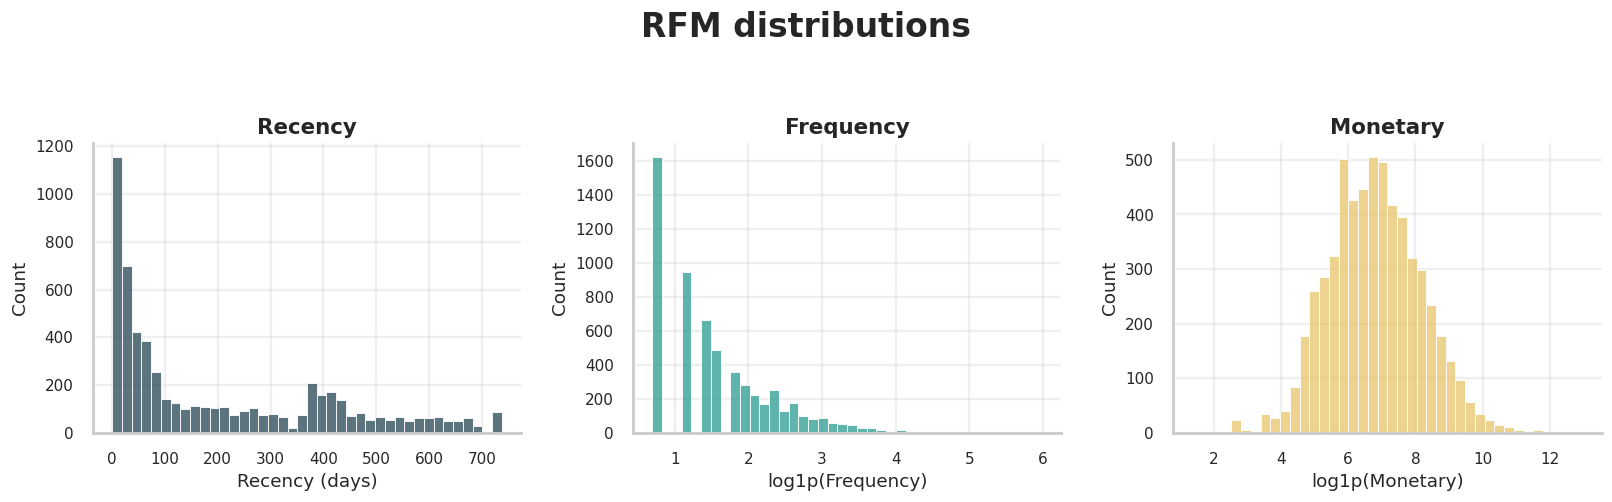

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, c in zip(axes, ['Recency', 'Frequency', 'Monetary'], PALETTE[:3]):
    data = rfm[col]
    if col != 'Recency':
        data = np.log1p(data); ax.set_xlabel(f'log1p({col})')
    else:
        ax.set_xlabel(f'{col} (days)')
    sns.histplot(data, bins=40, ax=ax, color=c, edgecolor='white')
    ax.set_title(col)
fig.suptitle('RFM distributions', y=1.03, fontweight='bold')
fig.tight_layout(); savefig(fig, '01_rfm_distributions'); plt.show()

## 8. Churn labelling
Customer is labelled **churned** if active before 2011-09-01 AND has no purchase in the 90 days after.

In [12]:
churn = pp.label_churn(df)
print(f'Customers labelled: {len(churn):,}')
print(f'Churn rate: {churn["churn"].mean():.2%}')
churn['churn'].value_counts().rename({0:'retained',1:'churned'})

Customers labelled: 5,249
Churn rate: 57.31%


churn
churned     3008
retained    2241
Name: count, dtype: int64

## 9. Persist artifacts

In [13]:
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
df.to_parquet(DATA_PROCESSED / 'transactions_clean.parquet', index=False)
rfm.to_csv(DATA_PROCESSED / 'rfm_features.csv', index=False)
churn.to_csv(DATA_PROCESSED / 'churn_labels.csv', index=False)

# Leakage-safe feature set for the churn classifier: built from pre-cutoff
# transactions with snapshot_date = CHURN_CUTOFF. Pair with churn_labels.csv.
cls_feats = pp.make_classification_features(df)
cls_feats.to_csv(DATA_PROCESSED / 'classification_features.csv', index=False)
print(f'classification_features.csv: {len(cls_feats):,} customers, max Recency={cls_feats["Recency"].max()} days')

print('Wrote:')
for p in DATA_PROCESSED.iterdir():
    print(f'  {p.name:35s} {p.stat().st_size/1024:>8.1f} KB')

classification_features.csv: 5,249 customers, max Recency=638 days
Wrote:
  .gitkeep                                 0.0 KB
  anomalous_customers.csv                 19.5 KB
  churn_labels.csv                        46.2 KB
  classification_features.csv            305.7 KB
  rfm_features.csv                       345.4 KB
  segments_agnes.csv                      51.7 KB
  segments_dbscan.csv                     52.1 KB
  segments_kmeans.csv                     51.7 KB
  splits.joblib                          839.5 KB
  transactions_clean.parquet            6295.5 KB


---
### Schema cheatsheet for downstream notebooks

| File | Key columns | Use |
|---|---|---|
| `transactions_clean.parquet` | Invoice, StockCode, Description, Quantity, InvoiceDate, Price, CustomerID, Country, TotalAmount | All notebooks |
| `rfm_features.csv` | CustomerID, Recency, Frequency, Monetary, avg_basket_value, avg_basket_size, unique_products, DominantCountry | Clustering / EDA (snapshot = 2011-12-10, full history) |
| `classification_features.csv` | same columns as `rfm_features.csv` | **Classification** (snapshot = `CHURN_CUTOFF` = 2011-09-01, pre-cutoff only — no target leakage) |
| `churn_labels.csv` | CustomerID, churn (0/1) | Classification label |